In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report

In [24]:
dataset = load_iris()
dataset.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [25]:
iris = pd.DataFrame(dataset.data,columns=dataset.feature_names)
iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [26]:
target = pd.Series(dataset.target)
target.head()

,0
0,0
1,0
2,0
3,0
4,0


In [27]:
dataset.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

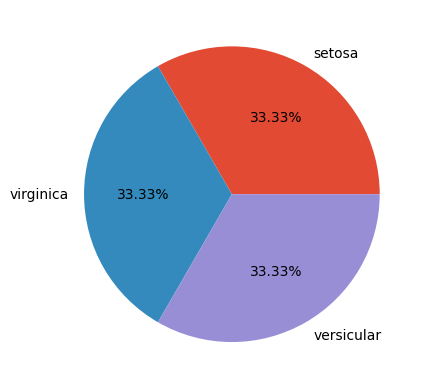

In [28]:
plt.style.use("ggplot")
plt.pie(target.value_counts(normalize=True),labels=['setosa','virginica','versicular'],autopct="%.2f%%")
plt.show()

In [29]:
target[target != 0] = 1

In [30]:
import numpy as np

class SVM:

    def __init__(self, ALPHA=0.001, lambda_param=0.01, n_iters=1000):
        self.ALPHA = ALPHA
        self.lambda_param = lambda_param
        self.n_iters = n_iters

    def fit(self, X, y):

        n_samples, n_features = X.shape

        y = np.where(y <= 0, -1, 1)

        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):

                condition = y[idx] * (np.dot(x_i, self.w) + self.b) >= 1

                if condition:
                    self.w -= self.ALPHA * (2 * self.lambda_param * self.w)

                else:
                    self.w -= self.ALPHA * (2 * self.lambda_param * self.w - y[idx] * x_i)
                    self.b -= self.ALPHA * y[idx]

    def predict(self, X):
        linear_output = np.dot(X, self.w) + self.b
        return np.sign(linear_output)

In [31]:

X_train, X_test, y_train, y_test = train_test_split(iris, target)

model = SVM()
model.fit(X_train.values, y_train.values)

predictions = model.predict(X_test)

In [32]:
predictions[predictions == -1] = 0
predictions

array([1., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 1.,
       1., 1., 1., 0., 1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1.,
       0., 0., 0., 1.])

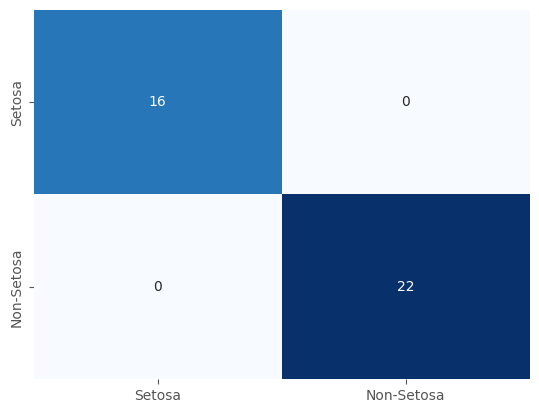

In [33]:
conf_matrix = confusion_matrix(y_pred=predictions,y_true=y_test)
sns.heatmap(conf_matrix,annot=True,cbar=False,cmap=plt.cm.Blues,xticklabels=["Setosa","Non-Setosa"],yticklabels=["Setosa","Non-Setosa"])
plt.show()

In [34]:
report = classification_report(y_pred=predictions,y_true=y_test,output_dict=True)
report = pd.DataFrame(report)
report

,0,1,accuracy,macro avg,weighted avg
precision,1.0,1.0,1.0,1.0,1.0
recall,1.0,1.0,1.0,1.0,1.0
f1-score,1.0,1.0,1.0,1.0,1.0
support,16.0,22.0,1.0,38.0,38.0
